# Notebook 01: Baseline Replication

**Goal:** Replicate the induction circuit in the pretrained `attn-only-2l` model.

**Outputs:** `experiments/results/baseline_induction_scores.npz`, `paper/figures/fig3_*`

**Runtime:** ~5 minutes on CPU.

In [2]:
import os

repo_url = 'https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning.git'
repo_name = 'Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning'

# Clone the repository if it doesn't already exist
if not os.path.exists(repo_name):
    print(f"Cloning {repo_url}...")
    !git clone {repo_url}
    print("Repository cloned.")
else:
    print(f"Repository '{repo_name}' already exists.")

# Change directory to the cloned repository
# This changes the current working directory for this cell and subsequent cells.
%cd /content/{repo_name}

# Completely purge existing torch/numpy and hidden cache files
print("Uninstalling existing Python packages...")
!pip uninstall -y torch torchvision torchaudio numpy
!rm -rf /usr/local/lib/python3.12/dist-packages/~*

# Perform a fresh installation of compatible versions
print("Installing compatible versions of required packages...")
!pip install "numpy>=2.0,<2.1" "torch>=2.4.0" "transformers>=4.44.0" "transformer_lens" --quiet

print("\nEnvironment setup complete. You MUST now go to Runtime -> Restart session for changes to take effect and proceed with the notebook execution.")


Cloning https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning.git...
Cloning into 'Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning'...
remote: Enumerating objects: 1277, done.
remote: Counting objects: 100% (485/485), done.
remote: Compressing objects: 100% (311/311), done.
remote: Total 1277 (delta 263), reused 333 (delta 161), pack-reused 792 (from 1)
Receiving objects: 100% (1277/1277), 5.26 MiB | 17.49 MiB/s, done.
Resolving deltas: 100% (645/645), done.
Filtering content: 100% (2/2), 206.61 MiB | 4.50 MiB/s, done.
Repository cloned.
/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning
Uninstalling existing Python packages...
Found existing installation: torch 2.7.1
Uninstalling torch-2.7.1:
  Successfully uninstalled torch-2.7.1
Found existing installation: torchvision 0.22.1
Uninstalling torchvision-0.22.1:
  Successfully uninstalled torchvision-0.22.1
Found

### Action Required: Restart Runtime

Please go to `Runtime` -> `Restart session` in the Colab menu.

After restarting, please re-run the cells below to ensure all necessary modules are correctly imported and the `sys.path` is properly configured.

In [1]:
import sys
import os
from pathlib import Path

# Set absolute path to repo root
repo_root = "/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print("Modules imported successfully from src.")


Device: cuda
Modules imported successfully from src.


In [2]:

import sys; sys.path.insert(0, '..')
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [3]:
model_config = ModelConfig()
eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)
print(f'Loaded: {model_config.source} | {model.cfg.n_layers}L {model.cfg.n_heads}H')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

./model_final.pth:   0%|          | 0.00/210M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda
Loaded: attn-only-2l | 2L 8H


In [4]:
means, stds = compute_induction_score_with_stats(
    model=model, sequence_length=eval_config.induction_seq_length,
    num_sequences=eval_config.induction_num_sequences, seed=eval_config.seed, device=device,
)
heads = identify_induction_heads(means, threshold=0.5)
print('Induction heads (>=0.5):', heads)
for l in range(model.cfg.n_layers):
    for h in range(model.cfg.n_heads):
        print(f'  L{l}H{h}: {means[l,h]:.3f} +/- {stds[l,h]:.3f}')


Induction heads (>=0.5): []
  L0H0: 0.001 +/- 0.000
  L0H1: 0.001 +/- 0.000
  L0H2: 0.004 +/- 0.001
  L0H3: 0.001 +/- 0.000
  L0H4: 0.005 +/- 0.001
  L0H5: 0.001 +/- 0.000
  L0H6: 0.004 +/- 0.001
  L0H7: 0.003 +/- 0.001
  L1H0: 0.006 +/- 0.003
  L1H1: 0.000 +/- 0.001
  L1H2: 0.001 +/- 0.002
  L1H3: 0.003 +/- 0.003
  L1H4: 0.000 +/- 0.001
  L1H5: 0.004 +/- 0.004
  L1H6: 0.408 +/- 0.103
  L1H7: 0.033 +/- 0.005


In [5]:
results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
np.savez(results_dir / 'baseline_induction_scores.npz',
         means=means.cpu().numpy(), stds=stds.cpu().numpy(),
         induction_heads=np.array(heads))
print('Saved.')

Saved.


In [6]:
from google.colab import files

file_path = results_dir / 'baseline_induction_scores.npz'
files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

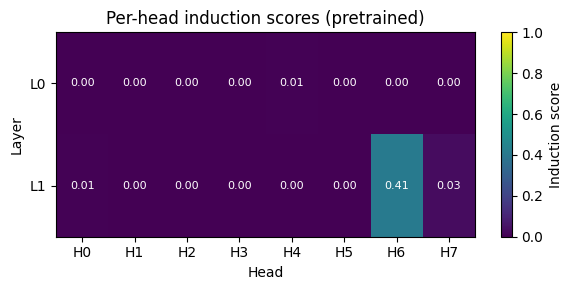

Figure 3 saved.


In [7]:

figures_dir = Path('../paper/figures'); figures_dir.mkdir(parents=True, exist_ok=True)
fig = plot_induction_score_heatmap(means.cpu().numpy(),
    title='Per-head induction scores (pretrained)',
    save_path=figures_dir / 'fig3_induction_scores_baseline')
plt.show()
print('Figure 3 saved.')

# Notebook 02: Activation Patching & Circuit Verification

**Goal:** Verify the causal role of induction heads.

**Outputs:** `experiments/results/baseline_attribution_scores.npz`, `paper/figures/fig1_*`, `paper/figures/fig4_*`

**Runtime:** ~15 minutes on CPU.

In [8]:
import sys; sys.path.insert(0, '..')
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.patching import compute_circuit_attribution, get_circuit_heads
from src.viz.circuit_diagram import plot_circuit_diagram, plot_attribution_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [9]:
model_config = ModelConfig(); eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


In [10]:

attribution_scores = compute_circuit_attribution(
    model=model, seq_len=20, batch_size=32, seed=eval_config.seed, device=device,
)
circuit_heads = get_circuit_heads(attribution_scores, threshold=eval_config.induction_circuit_threshold)
print('Circuit heads:', circuit_heads)
print('Max attribution:', attribution_scores.max().item())

Circuit heads: [(1, 6)]
Max attribution: 0.9521265029907227


In [11]:

results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
np.savez(results_dir / 'baseline_attribution_scores.npz',
         attribution_scores=attribution_scores.cpu().numpy(),
         circuit_heads=np.array(circuit_heads))
print('Saved.')


Saved.


In [12]:
from google.colab import files

# Define the full path to the saved file
file_to_download = Path('../experiments/results/baseline_attribution_scores.npz')

# Check if the file exists before attempting to download
if file_to_download.exists():
    print(f"Downloading {file_to_download.name}...")
    files.download(file_to_download)
else:
    print(f"Error: File not found at {file_to_download}. Please ensure the previous cells ran successfully.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

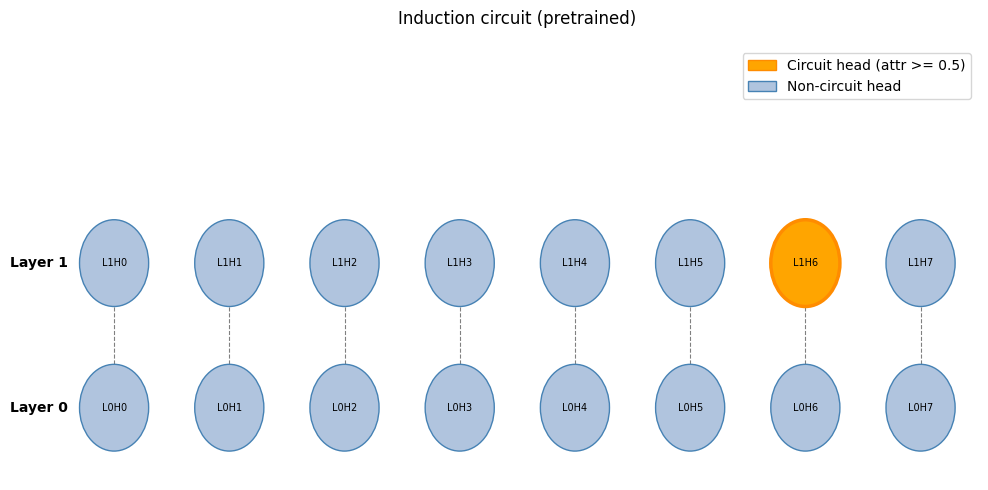

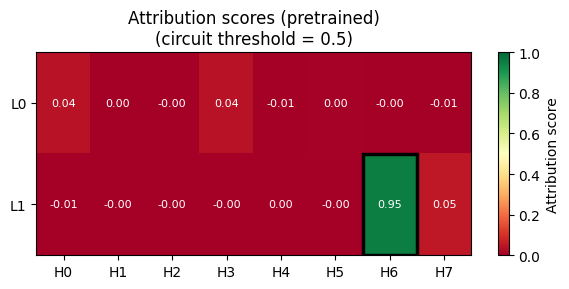

In [13]:
figures_dir = Path('../paper/figures'); figures_dir.mkdir(parents=True, exist_ok=True)
fig1 = plot_circuit_diagram(circuit_heads=circuit_heads, n_layers=model.cfg.n_layers, n_heads=model.cfg.n_heads,
    title='Induction circuit (pretrained)', save_path=figures_dir / 'fig1_circuit_diagram')
plt.show()
fig4 = plot_attribution_heatmap(attribution_scores.cpu().numpy(), threshold=eval_config.induction_circuit_threshold,
    title='Attribution scores (pretrained)', save_path=figures_dir / 'fig4_attribution_baseline')
plt.show()


# Notebook 03: Fine-Tuning Runs

**Goal:** Fine-tune on Python code (primary) and TinyStories prose (mandatory control).

**Outputs:** `checkpoints/code_seed*/`, `checkpoints/prose_seed*/`

**Runtime:** ~80 minutes per condition on Colab T4 GPU.

> **Note:** Both conditions are required. The prose control is mandatory for any domain-shift claim.


In [14]:
import sys; sys.path.insert(0, '..')
import torch
from src.model.config import ModelConfig, TrainConfig
from src.model.finetune import run_finetuning
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
model_config = ModelConfig()

Device: cuda


In [15]:
!grep -n "prepend_bos" /content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning/src/circuits/induction_score.py

22:invoked for this code path; prepend_bos has no effect here. We still pass
23:prepend_bos=False defensively and validate the cache shape is exactly
88:            prepend_bos=False,
103:                "and prepend_bos behaviour for the input type used."
185:            prepend_bos=False,


In [16]:

# --- Code fine-tuning (primary condition, 3 seeds) ---
for seed in [42, 123, 7]:
    print(f'\n=== Code, seed={seed} ===')
    cfg = TrainConfig(seed=seed, checkpoint_dir='../checkpoints', results_dir='../experiments/results')
    history = run_finetuning(model_config, cfg, run_name=f'code_seed{seed}', device=device, prose_control=False)
    print(f'Done: {len(history)} checkpoints')

2026-06-17T05:54:44 | INFO     | src.model.train | Global seed set to 42
2026-06-17T05:54:44 | INFO     | src.model.finetune | Fine-tuning run: code_seed42 | device: cuda
2026-06-17T05:54:44 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'



=== Code, seed=42 ===


2026-06-17T05:54:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T05:54:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T05:54:45 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T05:54:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T05:54:46 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T05:54:46 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelN

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T05:54:48 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T05:54:49 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T05:54:49 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T05:54:49 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/gpt-neox-tokenizer-digits/0f6671571a20be9756b9991d978047c03b75e749/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-17T05:54:49 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/gpt-neox-tokenizer-digits/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-17T05:54:49 | INFO    

...

Moving model to device:  cuda


2026-06-17T05:56:38 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/transformersbook/codeparrot/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-17T05:56:38 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/transformersbook/codeparrot/1525880546992f12c04c5ae4cf5c4d1e80ca04a4/README.md "HTTP/1.1 200 OK"
2026-06-17T05:56:39 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/transformersbook/codeparrot/resolve/1525880546992f12c04c5ae4cf5c4d1e80ca04a4/codeparrot.py "HTTP/1.1 404 Not Found"
2026-06-17T05:56:39 | INFO     | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/transformersbook/codeparrot/transformersbook/codeparrot.py "HTTP/1.1 404 Not Found"
2026-06-17T05:56:39 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/transformersbook/codeparrot/resolve/1525880546992f12c04c5ae4cf5c4d1e80ca04a4/.huggingface.yaml "HTTP/1.1 

Resolving data files:   0%|          | 0/184 [00:00<?, ?it/s]

2026-06-17T05:56:40 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/transformersbook/codeparrot/resolve/1525880546992f12c04c5ae4cf5c4d1e80ca04a4/dataset_infos.json "HTTP/1.1 404 Not Found"
2026-06-17T05:56:41 | INFO     | httpx | HTTP Request: GET https://huggingface.co/datasets/transformersbook/codeparrot/resolve/1525880546992f12c04c5ae4cf5c4d1e80ca04a4/file-000000000035.json.gz "HTTP/1.1 302 Found"
2026-06-17T05:56:41 | INFO     | httpx | HTTP Request: GET https://cas-bridge.xethub.hf.co/xet-bridge-us/621ffdd236468d709f184154/33ce5c52568ff202ed9a01aab26581f67dfffc6f6093897340431fce3be7c998?Expires=1781679400&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly9jYXMtYnJpZGdlLnhldGh1Yi5oZi5jby94ZXQtYnJpZGdlLXVzLzYyMWZmZGQyMzY0NjhkNzA5ZjE4NDE1NC8zM2NlNWM1MjU2OGZmMjAyZWQ5YTAxYWFiMjY1ODFmNjdkZmZmYzZmNjA5Mzg5NzM0MDQzMWZjZTNiZTdjOTk4KiIsIkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc4MTY3OTQwMH19fV19&Signature=MEUCIQD45PhMAQervbgm7SCOdAMJ2ye0rsVA4%7E

Done: 2 checkpoints


In [17]:
import os
import shutil
from pathlib import Path
from google.colab import files

def get_dir_size(path):
    total_size = 0
    if not path.exists():
        return 0
    if path.is_file(): # if it's a file, return its size directly
        return os.path.getsize(path)
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp): # avoid symbolic links
                total_size += os.path.getsize(fp)
    return total_size

# Define the directories
checkpoints_dir = Path('../checkpoints')
results_dir = Path('../experiments/results')

print("Checking directory sizes...")

# Check size of checkpoints directory
checkpoints_size_bytes = get_dir_size(checkpoints_dir)
checkpoints_size_mb = checkpoints_size_bytes / (1024 * 1024)
print(f"Total size of {checkpoints_dir}: {checkpoints_size_mb:.2f} MB")

# Check size of results directory
results_size_bytes = get_dir_size(results_dir)
results_size_mb = results_size_bytes / (1024 * 1024)
print(f"Total size of {results_dir}: {results_size_mb:.2f} MB")

print("\nCreating zip archive for results...")
# Create a zip archive of the results directory
output_archive_name = 'experiments_results'
output_path = Path('./') / output_archive_name # Current directory for the zip file

if results_dir.is_dir():
    try:
        shutil.make_archive(output_path, 'zip', results_dir)
        zipped_file_path = output_path.with_suffix('.zip')
        print(f"Successfully created {zipped_file_path.name}")
        print(f"Downloading {zipped_file_path.name}...")
        files.download(zipped_file_path)
    except Exception as e:
        print(f"Error creating or downloading zip file: {e}")
else:
    print(f"Results directory '{results_dir}' not found. Cannot create zip.")


Checking directory sizes...
Total size of ../checkpoints: 4191.39 MB
Total size of ../experiments/results: 0.00 MB

Creating zip archive for results...
Successfully created experiments_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:

# --- Prose control (mandatory, 3 seeds) ---
for seed in [42, 123, 7]:
    print(f'\n=== Prose, seed={seed} ===')
    cfg = TrainConfig(seed=seed, checkpoint_dir='../checkpoints', results_dir='../experiments/results')
    history = run_finetuning(model_config, cfg, run_name=f'prose_seed{seed}', device=device, prose_control=True)
    print(f'Done: {len(history)} checkpoints')


2026-06-17T05:57:41 | INFO     | src.model.train | Global seed set to 42
2026-06-17T05:57:41 | INFO     | src.model.finetune | Fine-tuning run: prose_seed42 | device: cuda
2026-06-17T05:57:41 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'



=== Prose, seed=42 ===


2026-06-17T05:57:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T05:57:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T05:57:41 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T05:57:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T05:57:42 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T05:57:42 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelN

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T05:57:44 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T05:57:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T05:57:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T05:57:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/gpt-neox-tokenizer-digits/0f6671571a20be9756b9991d978047c03b75e749/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-17T05:57:45 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/gpt-neox-tokenizer-digits/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-17T05:57:45 | INFO    

...

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:00:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T06:00:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T06:00:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:00:41 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/gpt-neox-tokenizer-digits/0f6671571a20be9756b9991d978047c03b75e749/tokenizer_config.json "HTTP/1.1 200 OK"
2026-06-17T06:00:41 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/gpt-neox-tokenizer-digits/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-06-17T06:00:42 | INFO    

Moving model to device:  cuda


2026-06-17T06:00:44 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:00:44 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/roneneldan/TinyStories/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/README.md "HTTP/1.1 200 OK"
2026-06-17T06:00:44 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/roneneldan/TinyStories/resolve/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/TinyStories.py "HTTP/1.1 404 Not Found"
2026-06-17T06:00:45 | INFO     | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/roneneldan/TinyStories/roneneldan/TinyStories.py "HTTP/1.1 404 Not Found"
2026-06-17T06:00:45 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/datasets/roneneldan/TinyStories/resolve/f54c09fd23315a6f9c86f9dc80f725de7d8f9c64/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-06-17T06:

Done: 2 checkpoints


In [19]:
import os
import shutil
from pathlib import Path
from google.colab import files

def get_dir_size(path):
    total_size = 0
    if not path.exists():
        return 0
    if path.is_file():
        return os.path.getsize(path)
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            if not os.path.islink(fp):
                total_size += os.path.getsize(fp)
    return total_size

# Define the directories
checkpoints_dir = Path('../checkpoints')
results_dir = Path('../experiments/results')

print("Checking directory sizes...")

# Check size of checkpoints directory
checkpoints_size_bytes = get_dir_size(checkpoints_dir)
checkpoints_size_mb = checkpoints_size_bytes / (1024 * 1024)
print(f"Total size of {checkpoints_dir}: {checkpoints_size_mb:.2f} MB")

# Check size of results directory
results_size_bytes = get_dir_size(results_dir)
results_size_mb = results_size_bytes / (1024 * 1024)
print(f"Total size of {results_dir}: {results_size_mb:.2f} MB")

print("\nCollecting and zipping prose seed results...")

# Create a temporary directory to store selected files for zipping
tmp_zip_dir = Path('./prose_results_to_zip')
tmp_zip_dir.mkdir(exist_ok=True)

prose_files_found = False
# Copy only the prose_seed history files to the temporary directory
for item in results_dir.iterdir():
    if item.is_file() and item.name.startswith('prose_seed') and item.name.endswith('_history.npz'):
        shutil.copy(item, tmp_zip_dir)
        prose_files_found = True

if prose_files_found:
    # Create a zip archive of the temporary directory
    output_archive_name = 'prose_fine_tuning_results'
    output_path = Path('./') / output_archive_name

    try:
        shutil.make_archive(output_path, 'zip', tmp_zip_dir)
        zipped_file_path = output_path.with_suffix('.zip')
        print(f"Successfully created {zipped_file_path.name}")
        print(f"Downloading {zipped_file_path.name}...")
        files.download(zipped_file_path)
    except Exception as e:
        print(f"Error creating or downloading zip file: {e}")
    finally:
        # Clean up the temporary directory
        shutil.rmtree(tmp_zip_dir)
else:
    print(f"No prose_seed history files found in '{results_dir}'. Cannot create zip.")



Checking directory sizes...
Total size of ../checkpoints: 8382.77 MB
Total size of ../experiments/results: 0.01 MB

Successfully created prose_fine_tuning_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Notebook 04: Checkpoint Sweep, Phase Detection & Adversarial Probes

**Prerequisites:** Notebook 03 must have completed.

**Outputs:** `experiments/results/sweep_*.npz`, `phase_transitions.json`, `adversarial_pre_post.npz`

In [20]:

import sys; sys.path.insert(0, '..')
import json, numpy as np, torch
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, load_checkpoint, set_global_seed
from src.analysis.checkpoint_sweep import sweep_checkpoints, load_sweep_results
from src.analysis.phase_detection import detect_phase_transitions, summarise_transitions, detect_circuit_dissolution_step
from src.analysis.adversarial import compare_adversarial_pre_post

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
model_config = ModelConfig(); eval_config = EvalConfig()


2026-06-17T06:01:50 | INFO     | src.model.train | Global seed set to 42


In [21]:
# Sweep code checkpoints (primary seed)
code_results = sweep_checkpoints(
    checkpoint_dir=Path('../checkpoints/code_seed42'),
    model_config=model_config, eval_config=eval_config,
    output_path=results_dir / 'sweep_code_seed42.npz', device=device,
)
print(f"Steps: {code_results['steps']}")
print(f"IS range: {code_results['induction_scores'].min():.3f} - {code_results['induction_scores'].max():.3f}")

2026-06-17T06:01:50 | INFO     | src.model.train | Global seed set to 42
2026-06-17T06:01:50 | INFO     | src.analysis.checkpoint_sweep | Sweeping 3 checkpoints in ../checkpoints/code_seed42 on cuda
2026-06-17T06:01:50 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'
2026-06-17T06:01:51 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:01:51 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:01:51 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:01:51 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/mai

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:01:55 | INFO     | src.model.train | Loaded checkpoint step=0 (timestamp: 2026-06-17T05:54:51.368083Z)
2026-06-17T06:01:55 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 0: pass tokenizer= to get real values.
2026-06-17T06:01:56 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:01:56 | INFO     | src.analysis.checkpoint_sweep |   step=0 | train_loss=nan | IS_mean=0.0297 | task_loss=11.8481 | ld_clean=4.6309 | ld_corr=1.1067 | n_circuit=1
2026-06-17T06:01:56 | INFO     | src.analysis.checkpoint_sweep | Processing: step_000100.pt
2026-06-17T06:01:58 | INFO     | src.model.train | Loaded checkpoint step=100 (timestamp: 2026-06-17T05:55:10.940066Z)
2026-06-17T06:01:58 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 100: pass tokenizer= to get real values.
2026-06-17T06:01:59 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:01:59 | INFO     | src.analysis

Steps: [  0 100 200]
IS range: 0.000 - 0.638


In [22]:
from google.colab import files

file_path = results_dir / 'sweep_code_seed42.npz'
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
# Sweep prose checkpoints
prove_results = sweep_checkpoints(
    checkpoint_dir=Path('../checkpoints/prose_seed42'),
    model_config=model_config, eval_config=eval_config,
    output_path=results_dir / 'sweep_prose_seed42.npz', device=device,
)
print('Prose sweep done.')


2026-06-17T06:02:03 | INFO     | src.model.train | Global seed set to 42
2026-06-17T06:02:03 | INFO     | src.analysis.checkpoint_sweep | Sweeping 3 checkpoints in ../checkpoints/prose_seed42 on cuda
2026-06-17T06:02:03 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'
2026-06-17T06:02:03 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:02:03 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:02:03 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:02:03 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/ma

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:02:07 | INFO     | src.model.train | Loaded checkpoint step=0 (timestamp: 2026-06-17T05:57:47.671100Z)
2026-06-17T06:02:07 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 0: pass tokenizer= to get real values.
2026-06-17T06:02:08 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:02:08 | INFO     | src.analysis.checkpoint_sweep |   step=0 | train_loss=nan | IS_mean=0.0297 | task_loss=11.8481 | ld_clean=4.6309 | ld_corr=1.1067 | n_circuit=1
2026-06-17T06:02:08 | INFO     | src.analysis.checkpoint_sweep | Processing: step_000100.pt
2026-06-17T06:02:10 | INFO     | src.model.train | Loaded checkpoint step=100 (timestamp: 2026-06-17T05:58:09.919138Z)
2026-06-17T06:02:11 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 100: pass tokenizer= to get real values.
2026-06-17T06:02:11 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:02:11 | INFO     | src.analysis

Prose sweep done.


In [24]:
from google.colab import files

file_path = results_dir / 'sweep_prose_seed42.npz'
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
for seed in [123, 7]:
    for condition in ['code', 'prose']:
        ckpt_dir = Path(f'../checkpoints/{condition}_seed{seed}')
        if not ckpt_dir.exists():
            print(f"⚠️  SKIPPING {condition} seed={seed}: checkpoint dir not found at {ckpt_dir}")
            continue
        print(f"\n=== Sweeping {condition}, seed={seed} ===")
        result = sweep_checkpoints(
            checkpoint_dir=ckpt_dir,
            model_config=model_config,
            eval_config=eval_config,
            output_path=results_dir / f'sweep_{condition}_seed{seed}.npz',
            device=device,
        )
        l1h6 = result['induction_scores'][:, 1, 6]
        print(f"  steps: {result['steps']}")
        print(f"  L1H6 trajectory: {l1h6}")

2026-06-17T06:02:15 | INFO     | src.model.train | Global seed set to 42
2026-06-17T06:02:15 | INFO     | src.analysis.checkpoint_sweep | Sweeping 3 checkpoints in ../checkpoints/code_seed123 on cuda
2026-06-17T06:02:15 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'



=== Sweeping code, seed=123 ===


2026-06-17T06:02:15 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:02:15 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:02:16 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:02:16 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T06:02:16 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T06:02:16 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelN

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:02:20 | INFO     | src.model.train | Loaded checkpoint step=0 (timestamp: 2026-06-17T05:55:43.019510Z)
2026-06-17T06:02:20 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 0: pass tokenizer= to get real values.
2026-06-17T06:02:21 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:02:21 | INFO     | src.analysis.checkpoint_sweep |   step=0 | train_loss=nan | IS_mean=0.0297 | task_loss=11.8481 | ld_clean=4.6309 | ld_corr=1.1067 | n_circuit=1
2026-06-17T06:02:21 | INFO     | src.analysis.checkpoint_sweep | Processing: step_000100.pt
2026-06-17T06:02:23 | INFO     | src.model.train | Loaded checkpoint step=100 (timestamp: 2026-06-17T05:56:03.088144Z)
2026-06-17T06:02:23 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 100: pass tokenizer= to get real values.
2026-06-17T06:02:24 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:02:24 | INFO     | src.analysis

...

  steps: [  0 100 200]
  L1H6 trajectory: [0.40827343 0.59340096 0.64470667]

=== Sweeping prose, seed=7 ===


2026-06-17T06:02:54 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:02:54 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:02:54 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:02:55 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T06:02:55 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 Not Found"
2026-06-17T06:02:55 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelN

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:02:58 | INFO     | src.model.train | Loaded checkpoint step=0 (timestamp: 2026-06-17T06:00:43.965100Z)
2026-06-17T06:02:59 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 0: pass tokenizer= to get real values.
2026-06-17T06:02:59 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:02:59 | INFO     | src.analysis.checkpoint_sweep |   step=0 | train_loss=nan | IS_mean=0.0297 | task_loss=11.8481 | ld_clean=4.6309 | ld_corr=1.1067 | n_circuit=1
2026-06-17T06:02:59 | INFO     | src.analysis.checkpoint_sweep | Processing: step_000100.pt
2026-06-17T06:03:02 | INFO     | src.model.train | Loaded checkpoint step=100 (timestamp: 2026-06-17T06:01:11.150974Z)
2026-06-17T06:03:02 | WARNING  | src.analysis.checkpoint_sweep | code_icl_score skipped at step 100: pass tokenizer= to get real values.
2026-06-17T06:03:03 | INFO     | src.circuits.patching | Circuit heads (>=0.5): [(1, 6)]
2026-06-17T06:03:03 | INFO     | src.analysis

  steps: [  0 100 200]
  L1H6 trajectory: [0.40827343 0.58457005 0.614391  ]


In [26]:
import numpy as np

print("=== 3-SEED L1H6 SUMMARY ===\n")
for condition in ['code', 'prose']:
    print(f"{condition.upper()}:")
    trajectories = []
    for seed in [42, 123, 7]:
        path = results_dir / f'sweep_{condition}_seed{seed}.npz'
        if not path.exists():
            print(f"  seed {seed}: MISSING ({path})")
            continue
        data = np.load(path)
        l1h6 = data['induction_scores'][:, 1, 6]
        steps = data['steps']
        trajectories.append(l1h6)
        print(f"  seed {seed}: steps={steps}  L1H6={l1h6}")

    if len(trajectories) == 3:
        arr = np.array(trajectories)  # [3, n_checkpoints]
        print(f"  MEAN  L1H6: {arr.mean(0)}")
        print(f"  SD    L1H6: {arr.std(0)}")
        print(f"  -> Use these mean/SD values to add error-bar shading to")
        print(f"     fig5 (code) / fig6 (prose) in notebook 05.")
    else:
        print(f"  ⚠️  Only {len(trajectories)}/3 seeds available — cannot compute mean/SD yet.")
    print()


=== 3-SEED L1H6 SUMMARY ===

CODE:
  seed 42: steps=[  0 100 200]  L1H6=[0.40827343 0.5840331  0.6382814 ]
  seed 123: steps=[  0 100 200]  L1H6=[0.40827343 0.5967432  0.65566814]
  seed 7: steps=[  0 100 200]  L1H6=[0.40827343 0.59340096 0.64470667]
  MEAN  L1H6: [0.40827343 0.59139246 0.6462188 ]
  SD    L1H6: [0.         0.00537976 0.00717818]
  -> Use these mean/SD values to add error-bar shading to
     fig5 (code) / fig6 (prose) in notebook 05.

PROSE:
  seed 42: steps=[  0 100 200]  L1H6=[0.40827343 0.5833304  0.6158125 ]
  seed 123: steps=[  0 100 200]  L1H6=[0.40827343 0.58036536 0.6175734 ]
  seed 7: steps=[  0 100 200]  L1H6=[0.40827343 0.58457005 0.614391  ]
  MEAN  L1H6: [0.40827343 0.58275527 0.6159256 ]
  SD    L1H6: [0.         0.00176407 0.00130165]
  -> Use these mean/SD values to add error-bar shading to
     fig5 (code) / fig6 (prose) in notebook 05.



In [27]:

# Phase transition detection
trans_code = detect_phase_transitions(code_results['steps'], code_results['induction_scores'],
    threshold=eval_config.phase_threshold, window=eval_config.phase_window)
trans_prose = detect_phase_transitions(prove_results['steps'], prove_results['induction_scores'],
    threshold=eval_config.phase_threshold, window=eval_config.phase_window)
print('Code:', summarise_transitions(trans_code))
print('Prose:', summarise_transitions(trans_prose))
with open(results_dir / 'phase_transitions.json', 'w') as f:
    json.dump({'code': trans_code, 'prose': trans_prose}, f, indent=2)

2026-06-17T06:03:06 | INFO     | src.analysis.phase_detection | Phase transitions detected: 1 (threshold=0.10)
2026-06-17T06:03:06 | INFO     | src.analysis.phase_detection | Phase transitions detected: 1 (threshold=0.10)


Code: {'n_degradations': 0, 'n_improvements': 1, 'earliest_step': 100, 'earliest_step_fraction': 0.5, 'heads_affected': [(1, 6)], 'mean_delta': 0.17575964331626892}
Prose: {'n_degradations': 0, 'n_improvements': 1, 'earliest_step': 100, 'earliest_step_fraction': 0.5, 'heads_affected': [(1, 6)], 'mean_delta': 0.17505696415901184}


In [28]:
from google.colab import files

file_path = results_dir / 'phase_transitions.json'
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
from src.analysis.adversarial import build_adversarial_suite, evaluate_adversarial_suite

# Adversarial probes
model_pre = load_pretrained_model(model_config, device=device)
load_checkpoint(Path('../checkpoints/code_seed42/step_000000.pt'), model_pre)
model_post = load_pretrained_model(model_config, device=device)
last_ckpt = sorted(Path('../checkpoints/code_seed42').glob('step_*.pt'))[-1]
load_checkpoint(last_ckpt, model_post)

# FIX: The previous RuntimeError 'Expected a 'cpu' device type for generator but found 'cuda''
# indicated an issue within build_adversarial_suite when its 'device' parameter was 'cuda'.
# The new RuntimeError 'Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!'
# occurs in _compute_logit_diff when tensors are on mixed devices. This means that while
# build_adversarial_suite needs to run on CPU for its generator, the subsequent evaluation
# functions need the data on CUDA to match the models.
#
# The solution is to explicitly call build_adversarial_suite on CPU, and then move the
# resulting suite to the model's device (CUDA) before calling evaluate_adversarial_suite.

# 1. Build the adversarial suite on CPU to avoid the torch.Generator device error
#    (build_adversarial_suite and evaluate_adversarial_suite are already imported from src.analysis.adversarial in K_0bVB5l6-Uw)
temp_suite_cpu = build_adversarial_suite(vocab_size=model_pre.cfg.d_vocab, seq_len=20,
                                         batch_size=50, seed=42, device='cpu')

# 2. Move all tensors in the suite to the actual model device ('cuda')
# The line 'suspected_circuit_heads = get_circuit_heads(model_pre)' was incorrect here
# as get_circuit_heads expects attribution scores, not the model itself.
# It's also not used later in this part of the code, so it can be removed.
suite_on_model_device = {k: v.to(device) for k, v in temp_suite_cpu.items()}

# 3. Evaluate the adversarial suite using the models and the CUDA-moved suite
pre = evaluate_adversarial_suite(model_pre, suite_on_model_device, seq_len=20, device=device)
post = evaluate_adversarial_suite(model_post, suite_on_model_device, seq_len=20, device=device)

# Reconstruct the 'adv' dictionary as it would be from compare_adversarial_pre_post
adv = {'pre': pre, 'post': post}
adv['delta'] = {k: post.get(k, 0.0) - pre.get(k, 0.0) for k in pre}

np.savez(results_dir / 'adversarial_pre_post.npz',
         pre=list(adv['pre'].values()), post=list(adv['post'].values()),
         delta=list(adv['delta'].values()), names=list(adv['pre'].keys()))
print('Top deltas:', sorted(adv['delta'].items(), key=lambda x: abs(x[1]), reverse=True)[:5])

2026-06-17T06:03:06 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'
2026-06-17T06:03:07 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:03:07 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:03:07 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:03:07 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T06:03:07 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 No

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:03:11 | INFO     | src.model.train | Loaded checkpoint step=0 (timestamp: 2026-06-17T05:54:51.368083Z)
2026-06-17T06:03:11 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'
2026-06-17T06:03:11 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:03:11 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:03:11 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:03:11 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T06:03:12 | INFO     | httpx | HT

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:03:17 | INFO     | src.model.train | Loaded checkpoint step=200 (timestamp: 2026-06-17T05:55:27.642402Z)
2026-06-17T06:03:17 | INFO     | src.analysis.adversarial | Adversarial suite: 22 prompt types


Top deltas: [('all_same_token', -1.7091708699542263), ('long_lag_3', -0.050217949303669046), ('fully_random', -0.04901570354458032), ('cyclic_shift_1', -0.036898713092769625), ('competing_a', 0.027259851388252487)]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

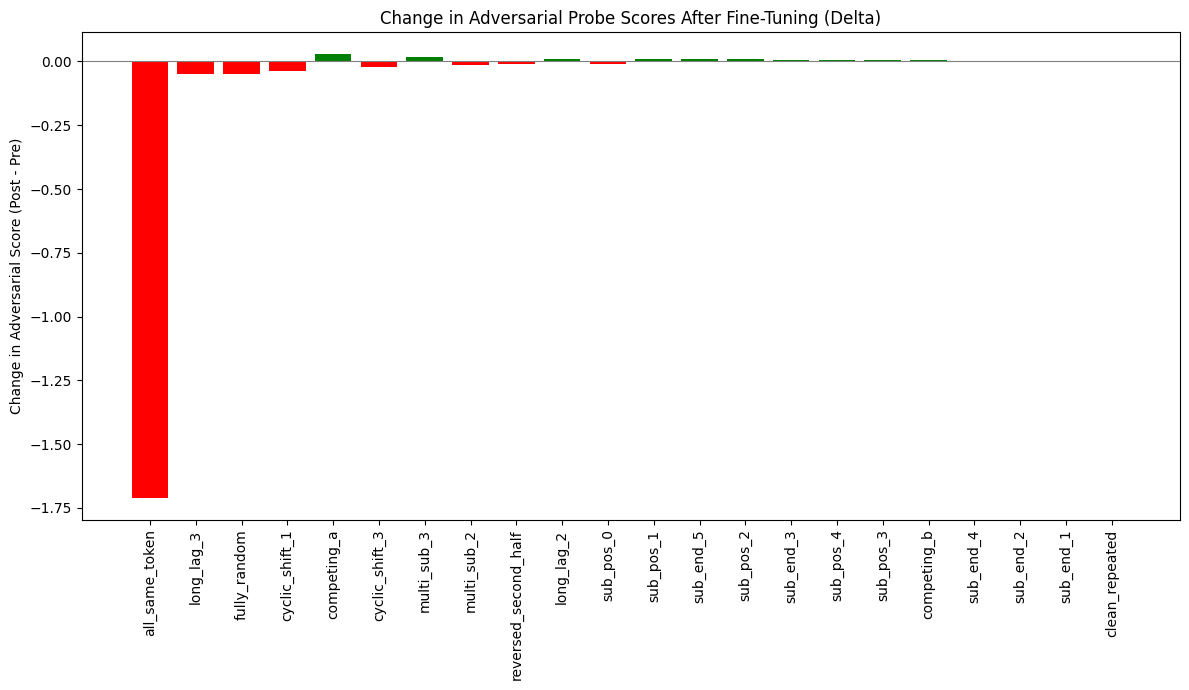

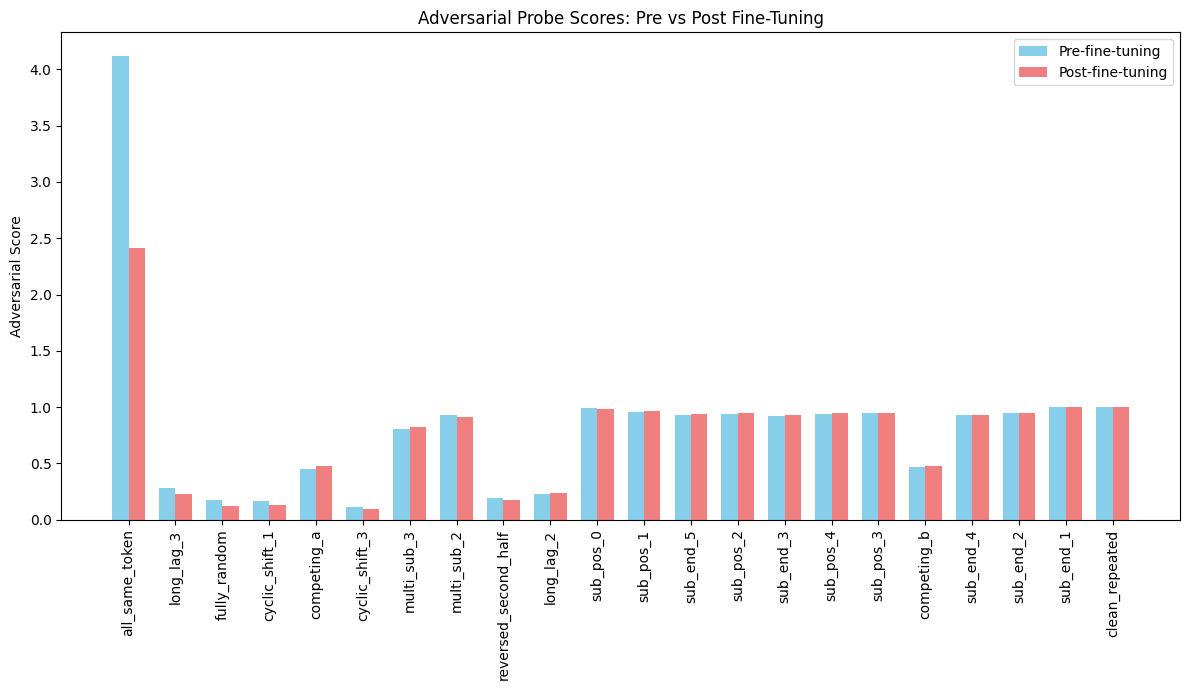

Adversarial probe graphs generated.


In [30]:
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np

# 1. Download adversarial_pre_post.npz
file_path_adv = results_dir / 'adversarial_pre_post.npz'
if file_path_adv.exists():
    print(f"Downloading {file_path_adv.name}...")
    files.download(file_path_adv)
else:
    print(f"Error: File not found at {file_path_adv}. Cannot download.")

# 2. Make appropriate graph of previous output (adversarial probes)
# Assuming 'adv' dictionary is available from the previous execution

if 'adv' in locals():
    probe_names = list(adv['pre'].keys())
    pre_scores = list(adv['pre'].values())
    post_scores = list(adv['post'].values())
    delta_scores = list(adv['delta'].values())

    # Sort by absolute delta for better visualization
    sorted_indices = np.argsort(np.abs(delta_scores))[::-1]
    sorted_probe_names = [probe_names[i] for i in sorted_indices]
    sorted_pre_scores = [pre_scores[i] for i in sorted_indices]
    sorted_post_scores = [post_scores[i] for i in sorted_indices]
    sorted_delta_scores = [delta_scores[i] for i in sorted_indices]

    fig, ax = plt.subplots(figsize=(12, 7))

    # Plotting deltas
    bars = ax.bar(sorted_probe_names, sorted_delta_scores, color=['g' if d > 0 else 'r' for d in sorted_delta_scores])
    ax.set_ylabel('Change in Adversarial Score (Post - Pre)')
    ax.set_title('Change in Adversarial Probe Scores After Fine-Tuning (Delta)')
    ax.tick_params(axis='x', rotation=90)
    ax.axhline(0, color='grey', linewidth=0.8)
    plt.tight_layout()
    plt.show()

    # Optionally, plot pre vs post side-by-side for more detail
    fig2, ax2 = plt.subplots(figsize=(12, 7))
    x = np.arange(len(sorted_probe_names))
    width = 0.35

    ax2.bar(x - width/2, sorted_pre_scores, width, label='Pre-fine-tuning', color='skyblue')
    ax2.bar(x + width/2, sorted_post_scores, width, label='Post-fine-tuning', color='lightcoral')

    ax2.set_ylabel('Adversarial Score')
    ax2.set_title('Adversarial Probe Scores: Pre vs Post Fine-Tuning')
    ax2.set_xticks(x)
    ax2.set_xticklabels(sorted_probe_names, rotation=90)
    ax2.legend()
    plt.tight_layout()
    plt.show()

    print("Adversarial probe graphs generated.")
else:
    print("Adversarial data (variable 'adv') not found. Please ensure the previous cell ran successfully.")

# Notebook 05: Paper Figures

**Single source of truth for all paper figures.**
Run top-to-bottom after notebooks 01-04. Never edit figure files manually.

| Figure | Description | Paper |
|--------|-------------|-------|
| fig1_circuit_diagram | Circuit schematic | Sec 3 |
| fig2_attention_heatmap | Attention pattern, top IS head | Sec 3 |
| fig3_induction_scores_baseline | Per-head IS, pretrained | Sec 4 |
| fig4_attribution_baseline | Attribution heatmap | Sec 4 |
| fig5_induction_code | IS over code fine-tuning | Sec 5 |
| fig6_induction_prose | IS over prose fine-tuning | Sec 5 |
| fig7_phase_transition | Phase transition detail | Sec 5 |
| fig8_adversarial | Adversarial probe results | Sec 5 |

In [31]:
import sys; sys.path.insert(0, '..')
import json, numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.analysis.checkpoint_sweep import load_sweep_results
from src.analysis.phase_detection import detect_phase_transitions
from src.viz.attention_vis import *
from src.viz.circuit_diagram import plot_circuit_diagram, plot_attribution_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
results_dir = Path('../experiments/results')
figures_dir = Path('../paper/figures'); figures_dir.mkdir(parents=True, exist_ok=True)

2026-06-17T06:03:20 | INFO     | src.model.train | Global seed set to 42


In [32]:
import numpy as np
from src.analysis.checkpoint_sweep import load_sweep_results

def load_averaged_sweep(condition, seeds=[42, 123, 7]):
    all_scores = []
    steps = None
    for seed in seeds:
        path = results_dir / f'sweep_{condition}_seed{seed}.npz'
        if path.exists():
            data = load_sweep_results(path)
            all_scores.append(data['induction_scores'])
            if steps is None: steps = data['steps']

    all_scores = np.stack(all_scores) # [seeds, steps, layers, heads]
    return {
        'steps': steps,
        'mean': np.mean(all_scores, axis=0),
        'std': np.std(all_scores, axis=0)
    }

# Load results and compute stats
baseline_ind = np.load(results_dir / 'baseline_induction_scores.npz')
baseline_attr = np.load(results_dir / 'baseline_attribution_scores.npz')

stats_code = load_averaged_sweep('code')
stats_prose = load_averaged_sweep('prose')

with open(results_dir / 'phase_transitions.json') as f: transitions_data = json.load(f)
adv_data = np.load(results_dir / 'adversarial_pre_post.npz', allow_pickle=True)
circuit_heads = [tuple(h) for h in baseline_attr['circuit_heads'].tolist()]
n_layers = baseline_ind['means'].shape[0]
n_heads = baseline_ind['means'].shape[1]
print(f'Averaged results across seeds for Code and Prose.')

Averaged results across seeds for Code and Prose.


2026-06-17T06:03:20 | INFO     | src.viz.circuit_diagram | Saved: ../paper/figures/fig1_circuit_diagram


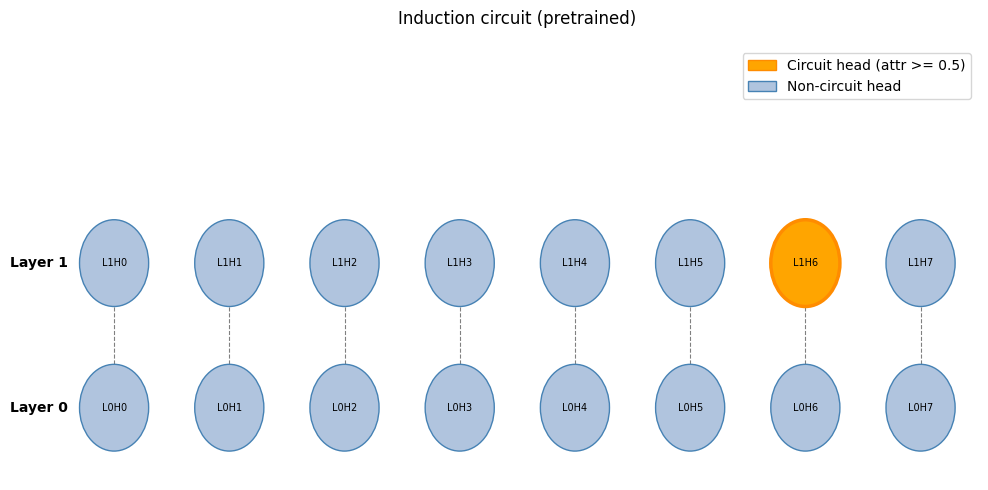

In [33]:
# Fig 1: Circuit diagram
fig1 = plot_circuit_diagram(circuit_heads, n_layers=n_layers, n_heads=n_heads,
    title='Induction circuit (pretrained)', save_path=figures_dir/'fig1_circuit_diagram')
plt.show(); plt.close(fig1)


2026-06-17T06:03:20 | INFO     | src.model.train | Loading model 'attn-only-2l' on device 'cuda'
2026-06-17T06:03:21 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-06-17T06:03:21 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/NeelNanda/Attn_Only_2L512W_C4_Code/4fb5f8490562081b69a0139e0469f36e88fdb160/config.json "HTTP/1.1 200 OK"
2026-06-17T06:03:21 | INFO     | httpx | HTTP Request: GET https://huggingface.co/api/models/NeelNanda/Attn_Only_2L512W_C4_Code/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-06-17T06:03:21 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/Attn_Only_2L512W_C4_Code/resolve/main/model_final.pth "HTTP/1.1 302 Found"
2026-06-17T06:03:22 | INFO     | httpx | HTTP Request: HEAD https://huggingface.co/NeelNanda/gpt-neox-tokenizer-digits/resolve/main/config.json "HTTP/1.1 404 No

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda


2026-06-17T06:03:25 | INFO     | src.viz.attention_vis | Figure saved: ../paper/figures/fig2_attention_heatmap (.pdf + .png)


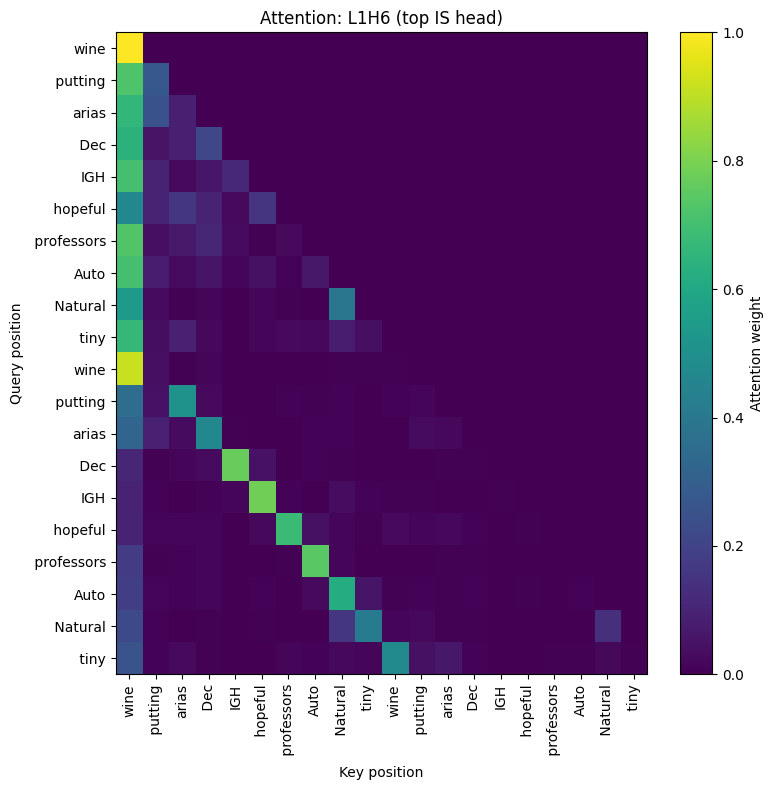

In [34]:
# Fig 2: Attention heatmap of top induction head
model = load_pretrained_model(ModelConfig(), device=device)
torch.manual_seed(42)
seq_len = 10
prefix = torch.randint(0, model.cfg.d_vocab, (1, seq_len), device=device)
tokens = torch.cat([prefix, prefix], dim=1)
top = np.unravel_index(baseline_ind['means'].argmax(), baseline_ind['means'].shape)
top_layer, top_head = int(top[0]), int(top[1])
fig2 = plot_attention_heatmap(model, tokens, top_layer, top_head,
    title=f'Attention: L{top_layer}H{top_head} (top IS head)',
    save_path=figures_dir/'fig2_attention_heatmap', device=device)
plt.show(); plt.close(fig2)

2026-06-17T06:03:26 | INFO     | src.viz.attention_vis | Figure saved: ../paper/figures/fig3_induction_scores_baseline (.pdf + .png)


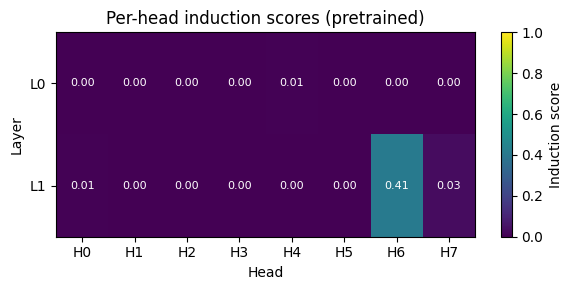

In [35]:
# Fig 3: Baseline IS heatmap
fig3 = plot_induction_score_heatmap(baseline_ind['means'],
    title='Per-head induction scores (pretrained)',
    save_path=figures_dir/'fig3_induction_scores_baseline')
plt.show(); plt.close(fig3)


2026-06-17T06:03:27 | INFO     | src.viz.circuit_diagram | Saved: ../paper/figures/fig4_attribution_baseline


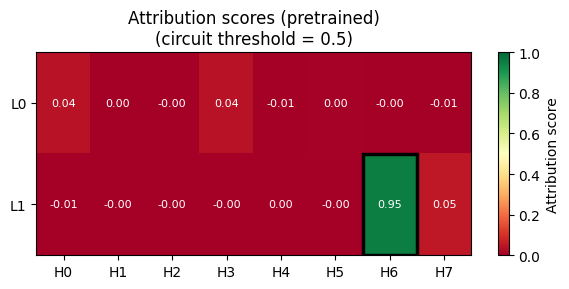

In [36]:
# Fig 4: Attribution heatmap
fig4 = plot_attribution_heatmap(baseline_attr['attribution_scores'], threshold=0.5,
    title='Attribution scores (pretrained)', save_path=figures_dir/'fig4_attribution_baseline')
plt.show(); plt.close(fig4)

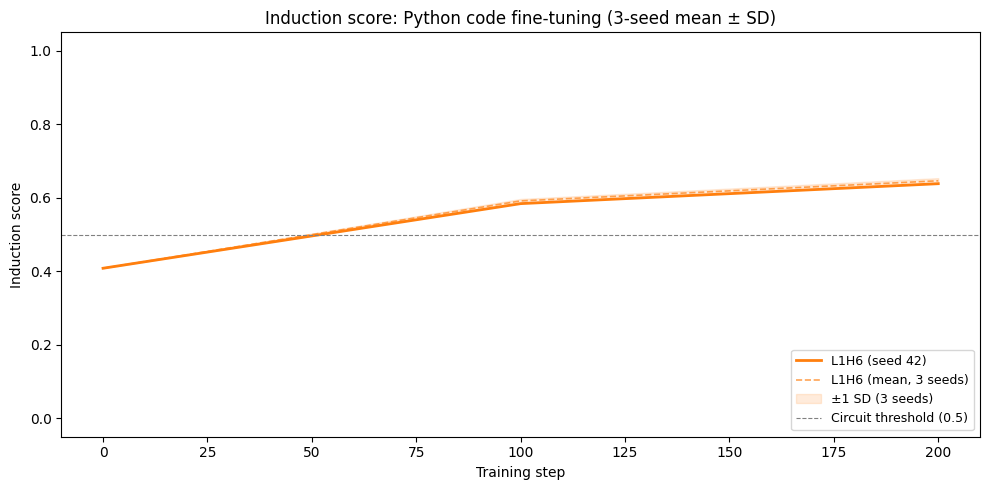

Saved fig5_induction_code.pdf / .png
  mean: [0.40827343 0.59139246 0.6462188 ]  sd: [0.         0.00537976 0.00717818]


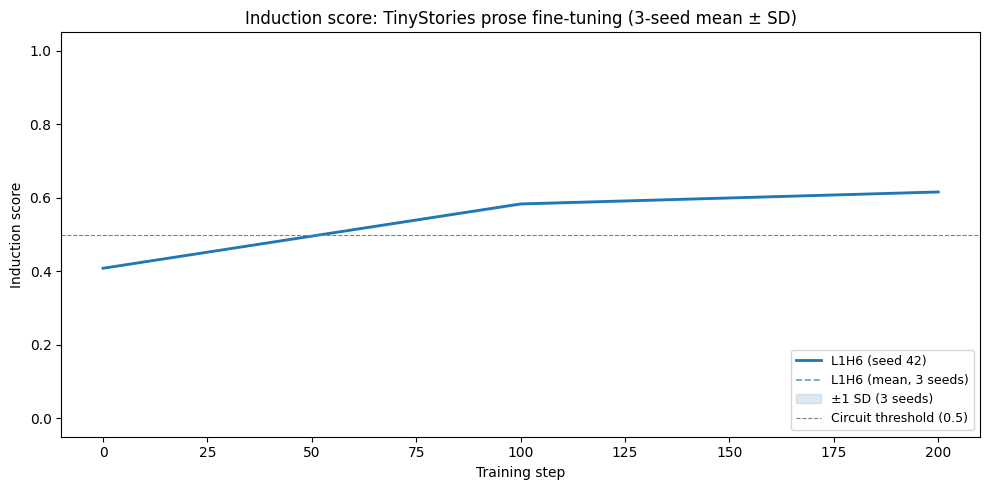

Saved fig6_induction_prose.pdf / .png
  mean: [0.40827343 0.58275527 0.6159256 ]  sd: [0.         0.00176407 0.00130165]


In [37]:

# ---------------------------------------------------------------------------
# CELL 3 (notebook 05) — Regenerate fig5/fig6 with 3-seed mean ± SD shading
# ---------------------------------------------------------------------------
# This REPLACES the existing fig5/fig6 generation cells in notebook 05.
# It plots the seed-42 line (as before, for continuity with the rest of the
# paper's per-checkpoint detail) but adds a shaded band showing mean ± 1 SD
# across all 3 seeds at each checkpoint, computed from the sweep files above.

import matplotlib.pyplot as plt

def plot_with_seed_band(condition: str, color: str, title: str, save_name: str):
    seeds = [42, 123, 7]
    trajectories, steps = [], None
    for seed in seeds:
        data = np.load(results_dir / f'sweep_{condition}_seed{seed}.npz')
        trajectories.append(data['induction_scores'][:, 1, 6])
        steps = data['steps']
    arr = np.array(trajectories)
    mean, sd = arr.mean(0), arr.std(0)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(steps, trajectories[0], color=color, linewidth=2.0, label='L1H6 (seed 42)')
    ax.plot(steps, mean, color=color, linewidth=1.2, linestyle='--',
             label='L1H6 (mean, 3 seeds)', alpha=0.7)
    ax.fill_between(steps, mean - sd, mean + sd, color=color, alpha=0.15,
                      label='±1 SD (3 seeds)')
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, label='Circuit threshold (0.5)')
    ax.set_xlabel('Training step'); ax.set_ylabel('Induction score')
    ax.set_ylim(-0.05, 1.05); ax.set_title(title)
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    fig.savefig(Path('../paper/figures') / f'{save_name}.pdf', bbox_inches='tight')
    fig.savefig(Path('../paper/figures') / f'{save_name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {save_name}.pdf / .png")
    print(f"  mean: {mean}  sd: {sd}")

plot_with_seed_band('code', 'tab:orange',
                     'Induction score: Python code fine-tuning (3-seed mean ± SD)',
                     'fig5_induction_code')
plot_with_seed_band('prose', 'tab:blue',
                     'Induction score: TinyStories prose fine-tuning (3-seed mean ± SD)',
                     'fig6_induction_prose')


2026-06-17T06:03:29 | INFO     | src.viz.attention_vis | Figure saved: ../paper/figures/fig7_phase_transition (.pdf + .png)


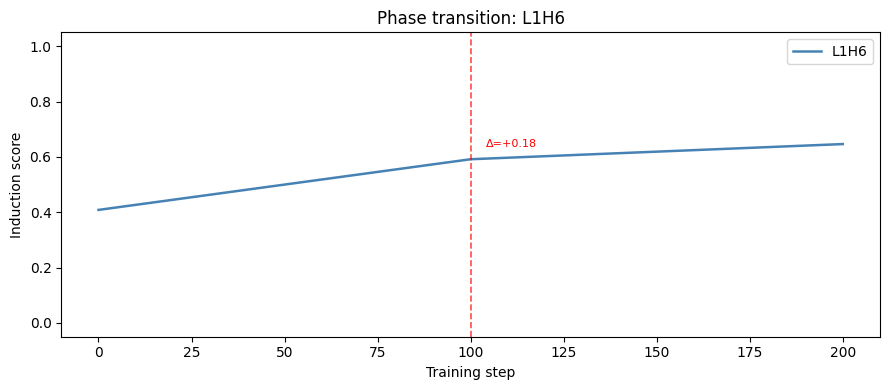

Phase transition: L1H6 delta=+0.176


In [38]:
# Fig 7: Phase transition for most-affected head
trans_code = transitions_data['code']
if trans_code:
    worst = max(trans_code, key=lambda t: abs(t['delta']))
    # Fix: use stats_code['steps'] and stats_code['mean'] instead of the deleted sweep_code variable
    fig7 = plot_phase_transition(
        stats_code['steps'],
        stats_code['mean'],
        trans_code,
        worst['layer'],
        worst['head'],
        save_path=figures_dir/'fig7_phase_transition'
    )
    plt.show(); plt.close(fig7)
    print(f"Phase transition: L{worst['layer']}H{worst['head']} delta={worst['delta']:+.3f}")
else:
    print('No phase transitions detected - skipping Fig 7.')

2026-06-17T06:03:30 | INFO     | src.viz.attention_vis | Figure saved: ../paper/figures/fig8_adversarial (.pdf + .png)


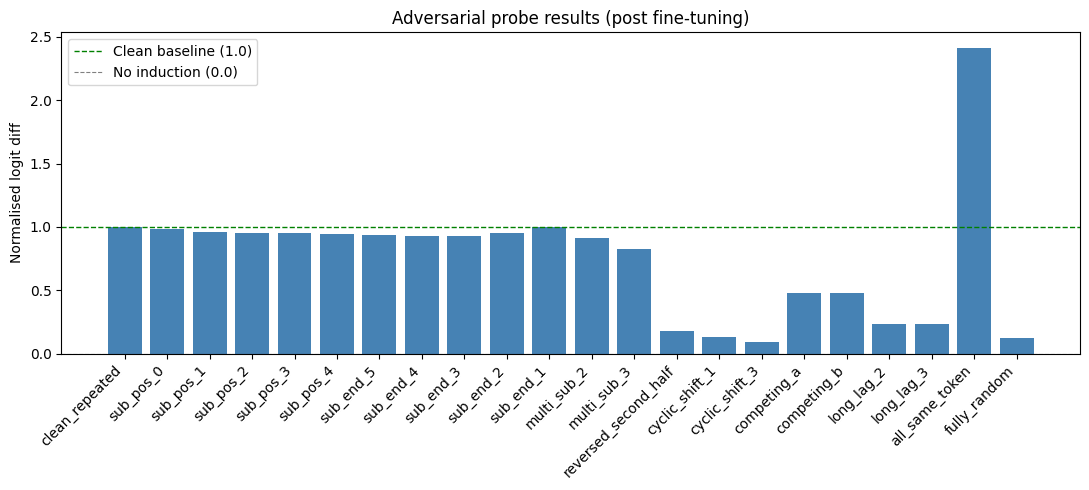

All figures saved to paper/figures/


In [39]:
# Fig 8: Adversarial probe results
names = [str(n) for n in adv_data['names'].tolist()]
post_scores = {names[i]: float(adv_data['post'][i]) for i in range(len(names))}
fig8 = plot_adversarial_results(post_scores, title='Adversarial probe results (post fine-tuning)',
    save_path=figures_dir/'fig8_adversarial')
plt.show(); plt.close(fig8)
print('All figures saved to paper/figures/')